# ===========================================================================
# 1. IMPORT LIBRARIES
# ===========================================================================

In [1]:
import io
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings

In [2]:
plt.style.use('default')
sns.set_theme(style="whitegrid", context="paper")

# ===========================================================================
# 2. FILE UPLOAD & LOADING LOGIC
# ===========================================================================

In [3]:
print(" Please upload your original 'gold_price.csv' file:")
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print("✔ File uploaded successfully.")
except Exception as e:
    sys.exit(f"❌ File Upload Failed: {e}")

👉 Please upload your original 'gold_price.csv' file:


Saving gold_price.csv to gold_price.csv
✔ File uploaded successfully.


# Dynamic header check based on your notebook rules

In [4]:
if 'Ticker' in str(df_raw.columns) or 'Price' in str(df_raw.columns):
    df = pd.read_csv(io.BytesIO(uploaded[file_name]), header=1)
else:
    df = df_raw.copy()

# ===========================================================================
# 3. DATA CLEANING & STRUCTURING
# ===========================================================================
# Selecting Target Columns (Date & Close Price)

In [5]:
try:
    df = df[['Date', 'Close']]
except KeyError:
    # Fallback to column index if names differ
    df = df.iloc[:, [0, 4]]

df.columns = ['date', 'price']

# Parsing Date Format safely

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

/tmp/ipykernel_7577/2412647424.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


# Parsing Numeric Prices & Index Sorting

In [7]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.sort_values('date')
df = df.set_index('date')

# Forward-fill any gaps/NaN values

In [8]:
df = df.ffill()

# ===========================================================================
# 4. DATA VISUALIZATION (PRE-TRAINING)
# ===========================================================================

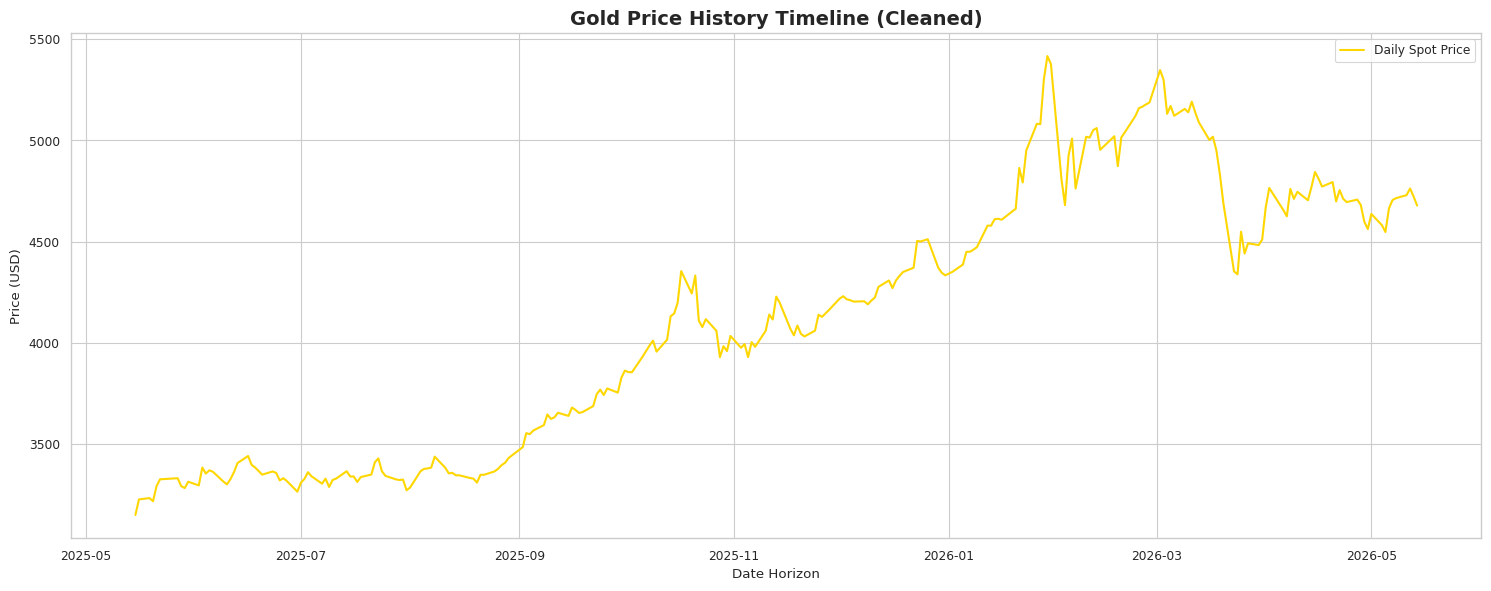

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df['price'], color='gold', linewidth=1.5, label='Daily Spot Price')
plt.title('Gold Price History Timeline (Cleaned)', fontweight='bold', fontsize=14)
plt.xlabel('Date Horizon')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# ===========================================================================
# 5. DATA EXPORT
# ===========================================================================

In [10]:
df.to_csv('cleaned_gold_price.csv')

print("\n" + "="*50)
print(f"✔ Dataset Integrity Check: SUCCESS")
print(f"✔ Total Data Points: {len(df)}")
print(f"✔ Covered Timeframe: {df.index.min().date()} to {df.index.max().date()}")
print(f"✔ Cleaned data saved as 'cleaned_gold_price.csv'")
print("="*50)


✔ Dataset Integrity Check: SUCCESS
✔ Total Data Points: 252
✔ Covered Timeframe: 2025-05-15 to 2026-05-14
✔ Cleaned data saved as 'cleaned_gold_price.csv'
